In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
titanic.shape

(891, 15)

In [7]:
# select the features and target columns 

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# impute the values 

imp_median = SimpleImputer(strategy="median")
titanic['age'] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy='most_frequent')
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode the values 

le = LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

In [8]:
titanic[features]
# titanic[target]

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0
...,...,...,...,...,...
886,2,1,13.0000,2,27.0
887,1,0,30.0000,2,19.0
888,3,0,23.4500,2,28.0
889,1,1,30.0000,0,26.0


In [9]:
# Convert values X and y

X = titanic[features]
y = titanic[target]

In [10]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [11]:
# Split the values in train and test splits 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [12]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [13]:
# Train the Model 

model = DecisionTreeClassifier(max_depth=4)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [14]:
# Predict the output from model

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [15]:
# Check The accuracy score

print("Training Accuracy : ", accuracy_score(y_train, y_pred_train)*100,"%")
print("Testing Acciracy : ", accuracy_score(y_test, y_pred_test)*100,"%")

Training Accuracy :  83.98876404494382 %
Testing Acciracy :  79.88826815642457 %


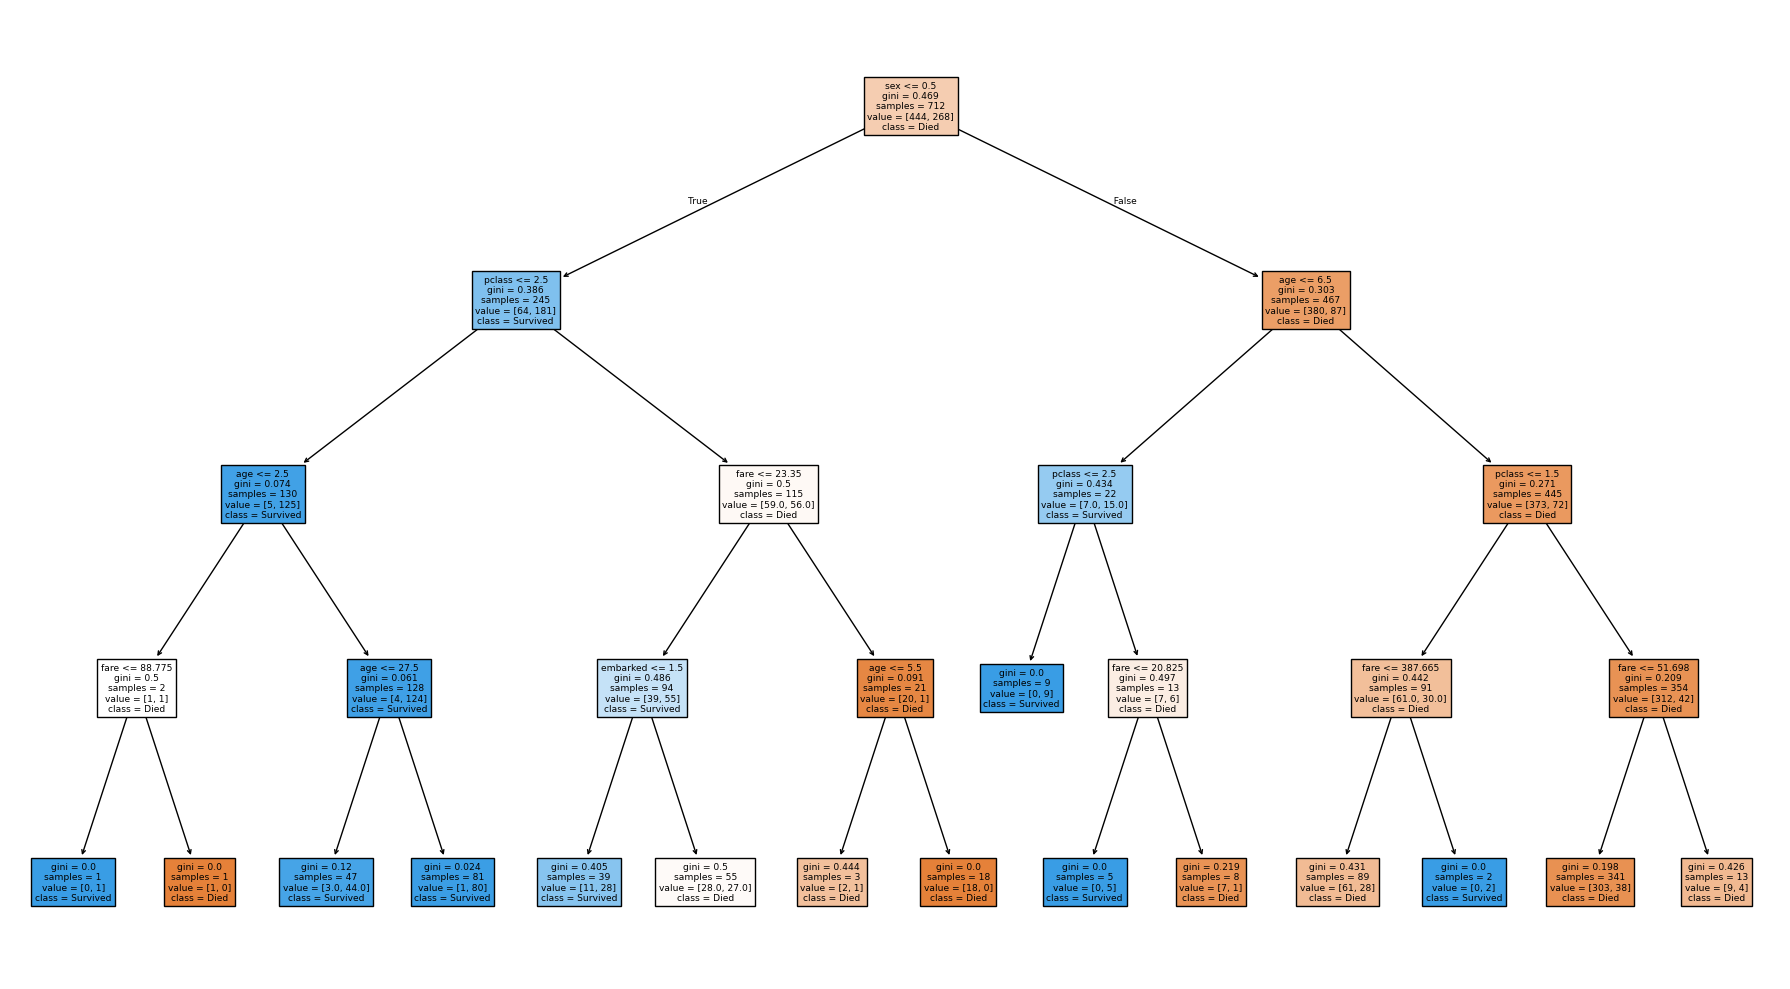

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['Died', 'Survived'],
    filled = True
)

plt.tight_layout()
plt.show()

In [17]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=501,
    oob_score = True,
    max_depth = 4
)
y_train = np.ravel(y_train)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred)*100,"%")
print("oob Score : ", rf.oob_score_*100,"%")

Accuracy Score :  81.56424581005587 %
oob Score :  82.58426966292134 %


In [18]:
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)
y_train = np.ravel(y_train)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred)*100,"%")

Accuracy Score :  80.44692737430168 %


In [19]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    logistic_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred)*100,"%")

Accuracy Score :  79.88826815642457 %
